# 기출문제 제10회(2025-06-21 시행)
---


## 작업형 제1유형
---

### 1. 소주제별로 정답률(정답여부가 1인 응답수/해당 소주제 전체 응답 수)을 구하고, 3번째로 높은 정답률을 구하시오.

In [194]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_1_1.csv")
df.head()

,학생ID,문제ID,대주제,소주제,정답여부
0,1001,1,과학,동물,0
1,1001,2,사회,정치,1
2,1001,3,과학,지구,0
3,1001,4,과학,식물,0
4,1001,5,수학,측정,1


In [195]:
df.shape

(1000, 5)

In [196]:
# 소주제별 정답률 계산
df['소주제'].value_counts()

소주제
동물     50
정치     50
지구     50
식물     50
측정     50
듣기     50
문화     50
도형     50
지리     50
화학     50
어휘     50
독해     50
쓰기     50
역사     50
경제     50
소수     50
분수     50
문법     50
방정식    50
물리     50
Name: count, dtype: int64

In [197]:
small_index = df['소주제'].value_counts().index
print(small_index)

Index(['동물', '정치', '지구', '식물', '측정', '듣기', '문화', '도형', '지리', '화학', '어휘', '독해',
       '쓰기', '역사', '경제', '소수', '분수', '문법', '방정식', '물리'],
      dtype='object', name='소주제')


In [198]:
# 소주제별 정답률 계산
small_mean = df.groupby('소주제')['정답여부'].mean()
"""
1. 소주제별로 묶는다.
2. 각 소주제의 총합을 구한다(50)
3. 소주제별 정답이 1인 경우의 총합을 구한다.
4. 3에서 2를 나눈다(오답은 0이므로 그냥 소주제별 정답여부의 평균을 구하면 된다.)
"""


'\n1. 소주제별로 묶는다.\n2. 각 소주제의 총합을 구한다(50)\n3. 소주제별 정답이 1인 경우의 총합을 구한다.\n4. 3에서 2를 나눈다(오답은 0이므로 그냥 소주제별 정답여부의 평균을 구하면 된다.)\n'

In [199]:
# 내림차순 정렬
small_mean.sort_values(ascending=False)

소주제
독해     0.74
듣기     0.70
문법     0.70
경제     0.68
지구     0.66
어휘     0.62
정치     0.62
역사     0.58
쓰기     0.54
분수     0.54
소수     0.54
화학     0.50
방정식    0.50
측정     0.48
지리     0.48
식물     0.48
문화     0.42
물리     0.42
도형     0.40
동물     0.32
Name: 정답여부, dtype: float64

문제의 요구사항대로 정답은 "문법"이 된다.

---

### 2. 제시된 문제를 순서대로 풀고, 해답을 제시하시오.

1. date를 연도(year), 월(month)로 분리하여, 연도-월별 price의 합계를 구하시오. 그 중 두 번째로 큰 매출액(합계)을 구하시오.

In [200]:
import pandas as pd

df2 = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_1_2.csv")
df2.head()

,date,category,item,price
0,2023-01-03,커피,라떼,46123
1,2023-02-05,커피,카푸치노,77519
2,2023-03-20,스무디,망고스무디,132181
3,2023-04-01,주스,오렌지주스,32901
4,2023-05-02,커피,카푸치노,84496


In [201]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      250 non-null    object
 1   category  250 non-null    object
 2   item      250 non-null    object
 3   price     250 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 7.9+ KB


In [202]:
df2['date'] = pd.to_datetime(df2['date'])
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      250 non-null    datetime64[ns]
 1   category  250 non-null    object        
 2   item      250 non-null    object        
 3   price     250 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.9+ KB


In [203]:
# 연도, 월 칼럼 생성
df2['year'] = df2['date'].dt.year
df2['month'] = df2['date'].dt.month
df2.head()

,date,category,item,price,year,month
0,2023-01-03,커피,라떼,46123,2023,1
1,2023-02-05,커피,카푸치노,77519,2023,2
2,2023-03-20,스무디,망고스무디,132181,2023,3
3,2023-04-01,주스,오렌지주스,32901,2023,4
4,2023-05-02,커피,카푸치노,84496,2023,5


In [204]:
# 연도-월별 price 총합 계산
total_price = df2.groupby(['year', 'month'])['price'].sum()
total_price

year  month
2023  1        1117426
      2        1167688
      3        1178860
      4         685229
      5         618655
      6        1196731
      7        1738018
      8         850558
      9        2096425
      10       1777389
      11        951424
      12       1151700
2024  1        1310043
      2         751392
      3         820949
      4         975772
      5        1141123
      6         861197
      7        1251005
      8        1033025
      9         877293
      10        818160
      11       1174466
      12       1533767
Name: price, dtype: int64

In [205]:
# 내림차순 정렬
total_price.sort_values(ascending=False)

year  month
2023  9        2096425
      10       1777389
      7        1738018
2024  12       1533767
      1        1310043
      7        1251005
2023  6        1196731
      3        1178860
2024  11       1174466
2023  2        1167688
      12       1151700
2024  5        1141123
2023  1        1117426
2024  8        1033025
      4         975772
2023  11        951424
2024  9         877293
      6         861197
2023  8         850558
2024  3         820949
      10        818160
      2         751392
2023  4         685229
      5         618655
Name: price, dtype: int64

문제의 요구사항대로 두 번째로 큰 매출액은 2023년 10월의 **1777389**이다.

2. 이전 문제에서 네 번째로 큰 price 합계에 해당하는 연도-월을 찾으시오. 해당 연도-월에서 카테고리(category)별 price 합계를 구하시오. 그 중 가장 높은 price 합계(정수)를 제출하시오.

In [206]:
# 위 내림차순 정렬을 통해 우리는 2024년 12월이 네 번째로 매출이 높은 달이라는 것을 알 수 있다.
total_category = df2[(df2['year'] == 2024) & (df2['month'] == 12)].groupby('category')['price'].sum().sort_values(ascending=False)
total_category

category
커피     1012500
스무디     269612
주스      251655
Name: price, dtype: int64

내림차순 정렬을 통해 카테고리별 매출액이 가장 높은 품목은 "커피"인 것을 알 수 있었다. 문제의 요구사항대로 price의 합계를 정수로 출력하면 아래 코드와 같다.

In [207]:
int(total_category['커피'])

1012500

---

### 3. 제시된 문제를 순서대로 풀고, 해답을 제시하시오.
1. 각 메시지의 단어 수를 공백(' ')을 기준으로 세는 새로운 칼럼을 만드시오.

In [208]:
import pandas as pd

df3 = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_1_3.csv")
df3.head()

,message,label
0,You have won a free vacation to Hawaii! Reply ...,spam
1,Your account will be locked in 24 hours. Act now.,spam
2,"Hey, are you coming to the meeting later?",ham
3,Don't forget to pick up milk on your way home.,ham
4,Special discount! 50% off on all shoes today o...,spam


In [209]:
df3['word_count'] = df3['message'].apply(lambda x : len(x.split()))
df3.head()

,message,label,word_count
0,You have won a free vacation to Hawaii! Reply ...,spam,12
1,Your account will be locked in 24 hours. Act now.,spam,10
2,"Hey, are you coming to the meeting later?",ham,8
3,Don't forget to pick up milk on your way home.,ham,10
4,Special discount! 50% off on all shoes today o...,spam,9


`.apply()`에 공백을 기준으로 문장을 리스트로 나누고 그 길이를 변수로하는 새로운 칼럼을 생성했다.(`"word_count"`)

2. 'spam'과 'ham' 각각의 평균 단어 수를 계산하시오.

In [210]:
label_mean = df3.groupby('label')['word_count'].mean()
label_mean

label
ham     6.232143
spam    6.531915
Name: word_count, dtype: float64

3. 두 평균의 차이의 절대값을 소수점 셋째자리까지 반올림하여 제출하시오.


In [211]:
print(abs(label_mean['ham'] - label_mean['spam']).round(3))
# 실수형 데이터 자릿수 조절은 .round() 함수를 사용한다. round(3)은 소수점 셋째 자리까지 반올림한다.

0.3


---

## 작업형 제2유형

제공된 학습용 데이터(`10_2_train.csv`)는 여러 상권 내 건물의 특성(상권 유형, 건물 면적, 건물 연식, 세대 수 등)과 연간 총 가스 소비량 정보를 담고 있다. 학습용 데이터를 활용하여 건물의 연간 총 가스 소비량(gas_totl)을 예측하는 모델을 개발하고, 이 중 가장 우수한 모델을 평가용 데이터(10_2_test.csv)에 적용하여 예측 결과를 제출하시오.

※평가 지표: RMSE

In [255]:
import pandas as pd

df_2_train = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_2_train.csv")
df_2_train.head()

,biz_type,area,age,num_households,gas_totl
0,public,93.291780,33,61,499
1,residential,97.509495,34,131,1156
2,residential,97.140181,5,30,392
3,residential,65.789408,12,166,1343
4,mixed,92.631000,28,14,154


In [256]:
df_2_test = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_2_test.csv")
df_2_test.fillna(0, inplace=True)
df_2_test.head()

,biz_type,area,age,num_households,gas_totl
0,industrial,86.256496,20,46,0.0
1,commercial,112.340076,31,112,0.0
2,industrial,116.323054,7,30,0.0
3,residential,86.620503,25,146,0.0
4,mixed,105.421235,17,14,0.0


In [214]:
df_2_train.shape

(160, 5)

In [215]:
df_2_test.shape

(40, 5)

In [216]:
df_2_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   biz_type        160 non-null    object 
 1   area            160 non-null    float64
 2   age             160 non-null    int64  
 3   num_households  160 non-null    int64  
 4   gas_totl        160 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 6.4+ KB


In [217]:
df_2_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   biz_type        40 non-null     object 
 1   area            40 non-null     float64
 2   age             40 non-null     int64  
 3   num_households  40 non-null     int64  
 4   gas_totl        40 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.7+ KB


In [257]:
# 데이터 형식 통일
df_2_test['gas_totl'] = df_2_test['gas_totl'].astype(int)
df_2_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   biz_type        40 non-null     object 
 1   area            40 non-null     float64
 2   age             40 non-null     int64  
 3   num_households  40 non-null     int64  
 4   gas_totl        40 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [219]:
df_2_test.head()

,biz_type,area,age,num_households,gas_totl
0,industrial,86.256496,20,46,0
1,commercial,112.340076,31,112,0
2,industrial,116.323054,7,30,0
3,residential,86.620503,25,146,0
4,mixed,105.421235,17,14,0


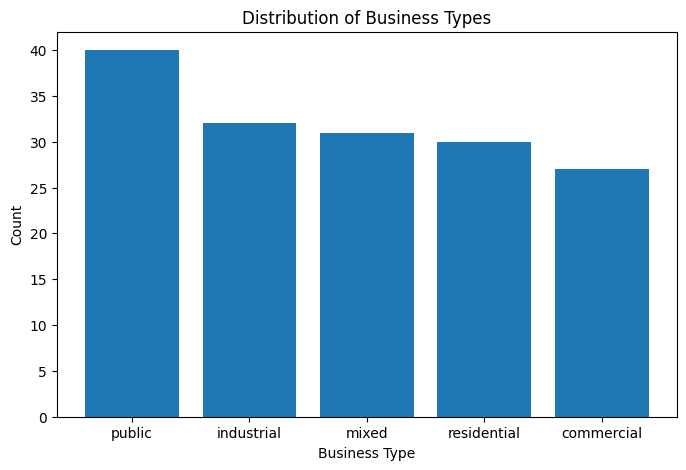

In [220]:
# EDA

# biz_type 칼럼의 고유값과 개수 확인
df_2_train['biz_type'].value_counts()

import matplotlib.pyplot as plt

# 막대그래프 시각화
plt.figure(figsize=(8, 5))
plt.bar(df_2_train['biz_type'].value_counts().index, df_2_train['biz_type'].value_counts().values)
plt.xlabel('Business Type')
plt.ylabel('Count')
plt.title('Distribution of Business Types')
plt.show()

In [221]:
df_2_train['biz_type'].value_counts()

biz_type
public         40
industrial     32
mixed          31
residential    30
commercial     27
Name: count, dtype: int64

In [258]:
# 자료형 데이터 수치형 데이터로 변환
df_2_train['biz_type_num'] = df_2_train['biz_type'].map({
    'public': 1, 
    'industrial': 2, 
    'mixed': 3, 
    'residential': 4, 
    'commercial': 5
    })

df_2_test['biz_type_num'] = df_2_test['biz_type'].map({
    'public': 1, 
    'industrial': 2, 
    'mixed': 3, 
    'residential': 4, 
    'commercial': 5
    })

df_2_train['biz_type_num'] = df_2_train['biz_type_num'].astype(int)
df_2_test['biz_type_num'] = df_2_test['biz_type_num'].astype(int)
df_2_test.head()

,biz_type,area,age,num_households,gas_totl,biz_type_num
0,industrial,86.256496,20,46,0,2
1,commercial,112.340076,31,112,0,5
2,industrial,116.323054,7,30,0,2
3,residential,86.620503,25,146,0,4
4,mixed,105.421235,17,14,0,3


In [223]:
df_2_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   biz_type        160 non-null    object 
 1   area            160 non-null    float64
 2   age             160 non-null    int64  
 3   num_households  160 non-null    int64  
 4   gas_totl        160 non-null    int64  
 5   biz_type_num    160 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 7.6+ KB


In [224]:
# 수치형 데이터 기술통계량
df_2_train.describe()

,area,age,num_households,gas_totl,biz_type_num
count,160.000000,160.000000,160.000000,160.000000,160.000000
mean,101.848971,25.100000,93.400000,780.112500,2.825000
std,19.607998,14.596976,56.013498,523.677718,1.429914
min,58.124120,1.000000,1.000000,0.000000,1.000000
25%,89.085818,12.000000,47.750000,383.500000,1.750000
50%,100.299131,25.500000,85.000000,761.500000,3.000000
75%,112.253448,38.000000,134.000000,1156.250000,4.000000
max,165.079703,49.000000,198.000000,1820.000000,5.000000


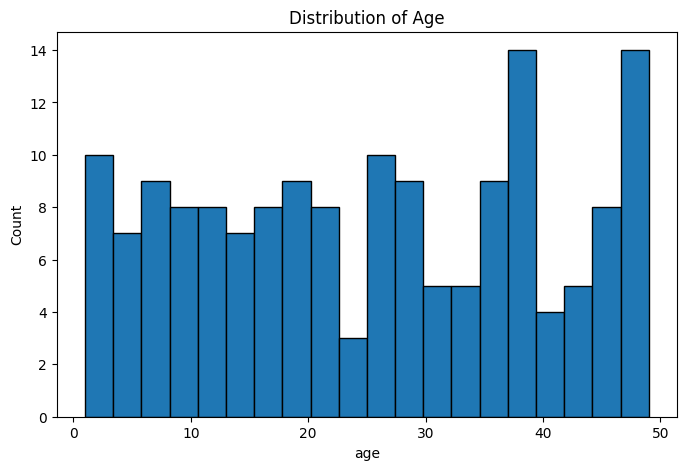

In [225]:
# Age 칼럼 데이터 분포 시각화
plt.figure(figsize=(8, 5))
plt.hist(df_2_train['age'], bins=20, edgecolor='k')
plt.xlabel('age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()

In [259]:
# 나이를 연령대별로 분할
def age_group(age):
    if age < 20:
        return 10
    elif age < 30:
        return 20
    elif age < 40:
        return 30   
    else:
        return 40
    
df_2_train['age_group'] = df_2_train['age'].apply(age_group)
df_2_train.head()

,biz_type,area,age,num_households,gas_totl,biz_type_num,age_group
0,public,93.291780,33,61,499,1,30
1,residential,97.509495,34,131,1156,4,30
2,residential,97.140181,5,30,392,4,10
3,residential,65.789408,12,166,1343,4,10
4,mixed,92.631000,28,14,154,3,20


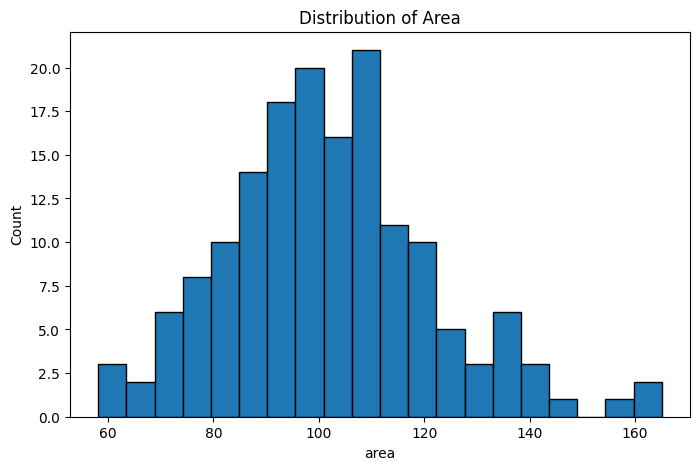

In [227]:
# area 시각화

plt.figure(figsize=(8, 5))
plt.hist(df_2_train['area'], bins=20, edgecolor='k')
plt.xlabel('area')
plt.ylabel('Count')
plt.title('Distribution of Area')
plt.show()

거의 정규분포를 띄고 있는 것을 볼 수 있다.

Text(0.5, 0, 'area')

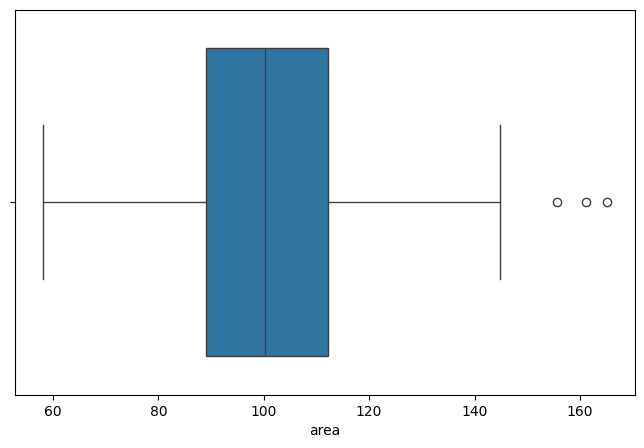

In [228]:
# area 칼럼 박스플롯

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_2_train['area'])
plt.xlabel('area')

150이상의 데이터는 이상치로 제거하고, 3개 등급 또는 5개 등급으로 분할해보자.

Text(0.5, 0, 'area')

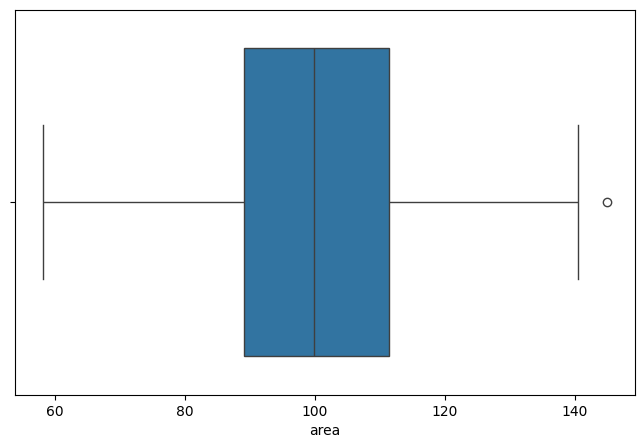

In [260]:
# area 칼럼 이상치 제거
Q1 = df_2_train['area'].quantile(0.25)
Q3 = df_2_train['area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_2_train = df_2_train[(df_2_train['area'] >= lower_bound) & (df_2_train['area'] <= upper_bound)]

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_2_train['area'])
plt.xlabel('area')


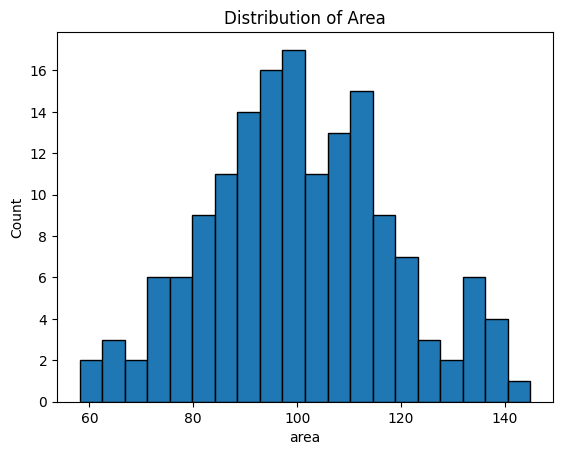

In [230]:
plt.hist(df_2_train['area'], bins=20, edgecolor='k')
plt.xlabel('area')
plt.ylabel('Count')
plt.title('Distribution of Area')
plt.show()

In [231]:
df_2_train['area'].describe()

count    157.000000
mean     100.725191
std       17.994321
min       58.124120
25%       89.045530
50%       99.768334
75%      111.355367
max      144.896132
Name: area, dtype: float64

In [261]:
# 3개 등급으로 area 칼럼 분할
def area_group(area):
    if area < 90:
        return 1
    elif area < 100:
        return 2
    else:
        return 3
    
df_2_train['area_group'] = df_2_train['area'].apply(area_group)
df_2_train.head()

,biz_type,area,age,num_households,gas_totl,biz_type_num,age_group,area_group
0,public,93.291780,33,61,499,1,30,2
1,residential,97.509495,34,131,1156,4,30,2
2,residential,97.140181,5,30,392,4,10,2
3,residential,65.789408,12,166,1343,4,10,1
4,mixed,92.631000,28,14,154,3,20,2


<Axes: >

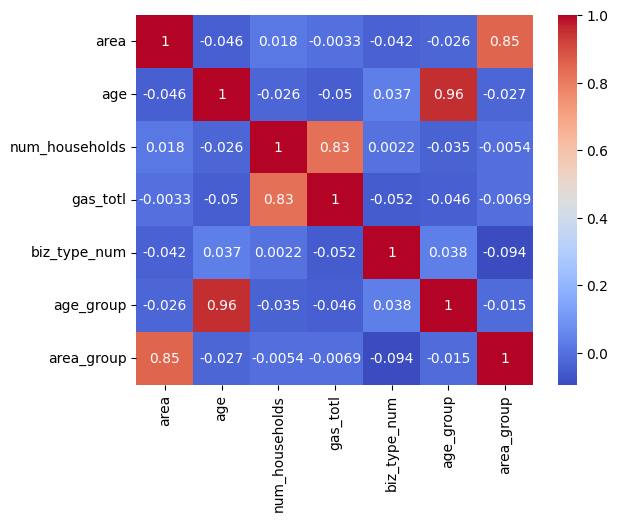

In [233]:
# 수치형 데이터 상관관계 확인
df_2_train_num = df_2_train.select_dtypes(include='number')

# 히트맵 시각화

sns.heatmap(df_2_train_num.corr(), annot=True, cmap='coolwarm')

In [234]:
df_2_train['num_households'].describe()

count    157.000000
mean      93.961783
std       56.204513
min        1.000000
25%       48.000000
50%       86.000000
75%      137.000000
max      198.000000
Name: num_households, dtype: float64

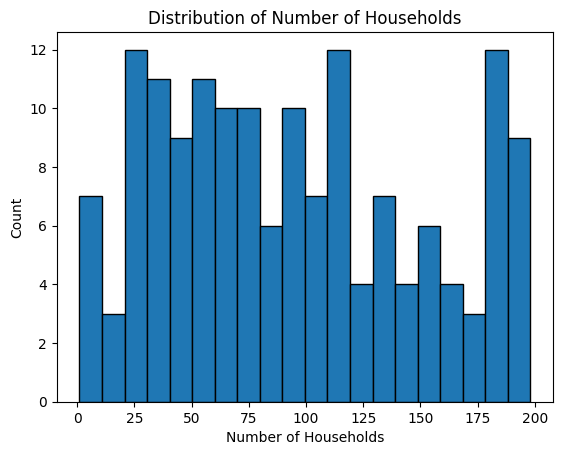

In [235]:
plt.hist(df_2_train['num_households'], bins=20, edgecolor='k')
plt.xlabel('Number of Households')
plt.ylabel('Count')
plt.title('Distribution of Number of Households')
plt.show()

Text(0.5, 0, 'Number of Households')

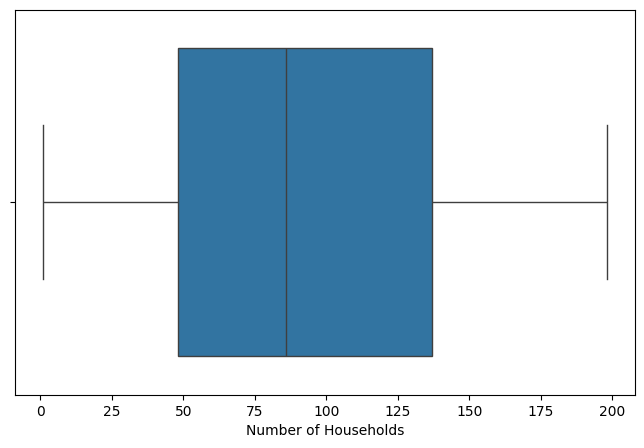

In [236]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_2_train['num_households'])
plt.xlabel('Number of Households')

In [262]:
# 3개 등급으로 num_households 칼럼 분할
def num_households_group(num_households):
    if num_households < 49:
        return 1
    elif num_households < 87:
        return 2
    else:
        return 3
    
df_2_train['num_households_group'] = df_2_train['num_households'].apply(num_households_group)
df_2_train.head()

,biz_type,area,age,num_households,gas_totl,biz_type_num,age_group,area_group,num_households_group
0,public,93.291780,33,61,499,1,30,2,2
1,residential,97.509495,34,131,1156,4,30,2,3
2,residential,97.140181,5,30,392,4,10,2,1
3,residential,65.789408,12,166,1343,4,10,1,3
4,mixed,92.631000,28,14,154,3,20,2,1


In [238]:
# 파생변수 생성에 의한 
df_target = df_2_train['gas_totl']
df_independent = df_2_train.drop(columns=['gas_totl'])
df_train = pd.concat([df_independent, df_target], axis=1)

df_train.head()

,biz_type,area,age,num_households,biz_type_num,age_group,area_group,num_households_group,gas_totl
0,public,93.291780,33,61,1,30,2,2,499
1,residential,97.509495,34,131,4,30,2,3,1156
2,residential,97.140181,5,30,4,10,2,1,392
3,residential,65.789408,12,166,4,10,1,3,1343
4,mixed,92.631000,28,14,3,20,2,1,154


<Axes: >

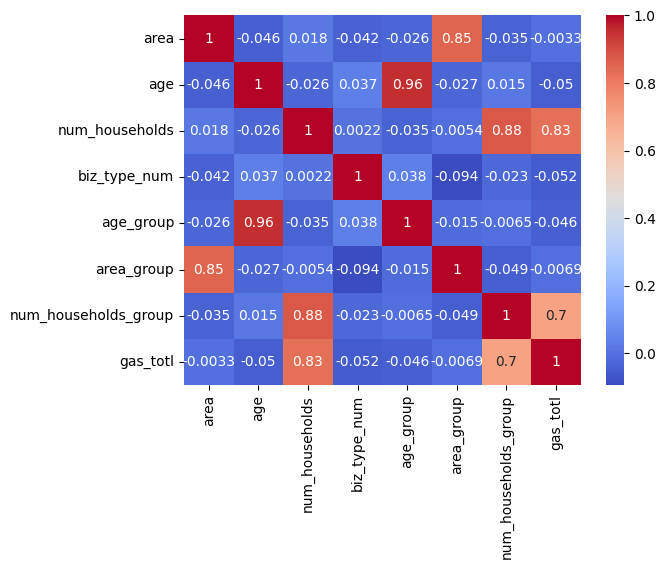

In [239]:
# 수치형 데이터 상관관계 확인
df_train_num = df_train.select_dtypes(include='number')

# 히트맵 시각화

sns.heatmap(df_train_num.corr(), annot=True, cmap='coolwarm')

데이터 탐색 결과, `"num_household"`를 제외한 모든 칼럼은 상관관계가 약한 것을 확인했다. 그리고 독립변수간에 상관관계도 파생변수를 제외하곤 거의 없는 것으로 확인하였다. `"num_household"`만 가지고 선형회귀 모델을 만들어보겠다. 

In [263]:
df_2_train = df_2_train.drop(columns=['biz_type', 'age_group', 'area_group', 'num_households_group'])
df_2_test = df_2_test.drop(columns=['biz_type'])


In [242]:
df_2_test.head()

,area,age,num_households,gas_totl,biz_type_num
0,86.256496,20,46,0,2
1,112.340076,31,112,0,5
2,116.323054,7,30,0,2
3,86.620503,25,146,0,4
4,105.421235,17,14,0,3


In [243]:
df_2_train.head()

,area,age,num_households,gas_totl,biz_type_num
0,93.291780,33,61,499,1
1,97.509495,34,131,1156,4
2,97.140181,5,30,392,4
3,65.789408,12,166,1343,4
4,92.631000,28,14,154,3


In [264]:
# 선형회귀 모델 학습
import sklearn.linear_model

linear_model = sklearn.linear_model.LinearRegression()

df_train = df_2_train.copy()

# 데이터 분할
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=['gas_totl'])
y = df_train['gas_totl']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model.fit(X_train, y_train)

# 검증 데이터 예측
y_val_pred = linear_model.predict(X_val)

# 테스트 데이터 예측
df_test = df_2_test.copy()
y_test_pred = linear_model.predict(df_test.drop(columns=['gas_totl']))

In [265]:
# RMSE 계산
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(round(rmse, 2))

288.22


In [267]:
# 상관관계가 높은 칼럼만 사용하여 학습

df_new = df_train[['num_households', 'gas_totl']]
df_new.head()

,num_households,gas_totl
0,61,499
1,131,1156
2,30,392
3,166,1343
4,14,154


In [268]:
df_new_test = df_2_test[['num_households', 'gas_totl']]
df_new_test.head()

,num_households,gas_totl
0,46,0
1,112,0
2,30,0
3,146,0
4,14,0


In [269]:
# 독립변수, 파생변수 선언
X_new = df_new.drop(columns=['gas_totl'])
y_new = df_new['gas_totl']

# 데이터 분할
X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [270]:
# 모델 학습

linear_new_model = sklearn.linear_model.LinearRegression()

linear_new_model.fit(X_new_train, y_new_train)

# 모델 평가
y_new_val_pred = linear_new_model.predict(X_new_val)

# 평가 지표 계산
rmse_new = np.sqrt(mean_squared_error(y_new_val, y_new_val_pred))
print(round(rmse_new, 2))

285.76


큰 차이는 없었다. 초안 모델로 최종 제츨 하겠다.

In [279]:
result = pd.DataFrame(y_test_pred, columns=["pred"])

result.to_csv("result.csv", index=False)

In [282]:
df_test.shape

(40, 5)

In [281]:
result.shape

(40, 1)

---

## 3. 작업형 제3유형

### (1) 한 기업이 인사관리 데이터를 가지고 이직 여부 예측 모델을 개발하려고 한다. 다음 문제를 풀이하시오.

In [283]:
import pandas as pd

df_3_1 = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_3_1.csv")
df_3_1.head()

,attrition,age,income,overtime
0,0,51,9270,0
1,0,23,9603,1
2,1,49,2860,2
3,0,56,7390,1
4,0,42,7226,2


In [284]:
df_3_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   attrition  200 non-null    int64
 1   age        200 non-null    int64
 2   income     200 non-null    int64
 3   overtime   200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [285]:
df_3_1.shape

(200, 4)

In [286]:
df_3_1.describe()

,attrition,age,income,overtime
count,200.000000,200.000000,200.000000,200.000000
mean,0.050000,40.990000,6133.490000,0.900000
std,0.218492,11.936595,2419.029427,0.802008
min,0.000000,20.000000,2034.000000,0.000000
25%,0.000000,30.000000,4045.500000,0.000000
50%,0.000000,43.000000,6207.000000,1.000000
75%,0.000000,51.000000,8286.000000,2.000000
max,1.000000,59.000000,9989.000000,2.000000


1. 이직 여부를 예측하는 로지스틱 회귀모형을 적합하고, 유의한 변수(유의확률 0.05 미만)의 회귀계수를 소수점 셋째 자리까지 반올림하여 제출하시오(단, 절편 제외)

In [292]:
# 모르는 것: 회귀계수 유의성 검증 방법

# Target: attrition

# 회귀계수 예측하는 방법
import statsmodels.formula.api as smf

model = smf.logit("attrition ~ age + income + C(overtime)", data=df_3_1).fit()
pvalues = model.pvalues
params = model.params
print(pvalues)


         Current function value: 0.048045
         Iterations: 35
Intercept           0.999667
C(overtime)[T.1]    0.997790
C(overtime)[T.2]    0.997772
age                 0.121215
income              0.009629
dtype: float64


c:\Users\hambu\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [293]:
# 유의확률 0.05미만, 절편 제외
sig_vars = params[pvalues < 0.05]
rounded_coefs = np.round(sig_vars, 3)
print(rounded_coefs)

income   -0.005
dtype: float64


2. age가 1 증가할 때 이직(또는 잔류) 오즈비(Odds ratio)를 소수점 셋째 자리까지 반올림하여 제출하시오.

In [294]:
age_coef = model.params['age']

# 오즈비 계산
odds_ratio_age = np.exp(age_coef)
odds_ratio_age_rounded = round(odds_ratio_age, 3)
print(odds_ratio_age_rounded)

0.894


3. age=20, income=3000, overtime=2 값을 가진 데이터의 이직확률을 모델로 예측하여 소수점 셋째 자리까지 반올림하여 제출하시오.

In [296]:
test_data = pd.DataFrame({
    "age": [20],
    "income": [3000],
    "overtime": [2]
})

pred_prob = model.predict(test_data)
pred_prob_rounded = round(pred_prob[0], 3) 
print(pred_prob_rounded)

0.48


---

### (2) 어느 지역의 주택들의 정보를 수집하여 주택 가격을 예측하는 모델을 개발하려고한다. 다음 문제를 풀이하시오.

1. 주택 가격을 예측하는 다중선형회귀모형을 적합하고, 유의한 변수(유의확률 0.05미만)의 회귀계수 합(절편 제외)을 소수점 셋째자리까지 반올림하여 제출하시오.
2. 유의한 변수만으로 다중선형회귀모형을 다시 적합하고, 결정계수를 소수점 셋째 자리까지 반올림하여 제출하시오.
3. area=100, height=10, wall=1 값을 가진 데이터의 예측 주택 가격을 모델로 예측하여 소수점 셋째 자리까지 반올림하여 제출하시오(단, 이전문제에서 뽑은 통계적으로 유의미한 변수만 선택할 것)

In [297]:
import pandas as pd

df_3_2 = pd.read_csv("https://raw.githubusercontent.com/YoungjinBD/data/main/exam/10_3_2.csv")
df_3_2.head()

,price,area,height,wall
0,317.312359,89.934283,10.715575,0
1,273.821798,77.234714,11.121569,0
2,319.961122,92.953771,12.166102,0
3,364.561162,110.460597,12.107604,1
4,254.338664,75.316933,7.244661,1


In [300]:
import statsmodels.formula.api as smf

model_2 = smf.ols("price ~ area + height + wall", data=df_3_2).fit()

params_2 = model_2.params[1:]
pvalues_2 = model_2.pvalues[1:]
print(pvalues_2)

area      3.018861e-79
height    5.178908e-21
wall      8.338266e-01
dtype: float64


In [302]:
sig_vars_2 = params_2[pvalues_2 < 0.05]
coef_sum = sig_vars_2.sum()
coef_rounded = np.round(coef_sum, 3)
print(coef_rounded)

10.289


In [304]:
# 유의미한 변수들로 다시 모델 학습

sig_var_names = sig_vars_2.index.to_list()

formula = "price ~ " + " + ".join(sig_var_names)
model2 = smf.ols(formula, data=df_3_2).fit()
r2_squred = np.round(model2.rsquared, 3)

print(r2_squred)

0.859


In [305]:
test_data_2 = pd.DataFrame({
    "area": [100],
    "height": [10],
    "wall": [1]
})
test_x = test_data_2[sig_var_names]
pred_prob_2 = model2.predict(test_x)
pred_prob_rounded = round(pred_prob_2[0], 3) 
print(pred_prob_rounded)

329.036
